# Reusable Non-Parametric Testing Template

A generic starting point for a **new** hypothesis-testing project. Copy this
notebook, plug in your own data at the marked spots, and follow the sections
in order. It's organized as a pipeline:

`Load data → Explore → Check assumptions → Pick a test (decision function
included) → Run it → Effect size → Report`

Everything here is written as small, reusable functions so you can also just
`import` this notebook's logic into a `.py` module for a real project.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from itertools import combinations

rng = np.random.default_rng(42)
ALPHA = 0.05  # <- set your significance level for the whole project here
%matplotlib inline

## 1. Load Your Data

Replace this cell with however you actually load your data: `pd.read_csv`,
a database query, an API pull, etc. The rest of the notebook assumes you end
up with either:
- two 1-D arrays (`sample_a`, `sample_b`) for a two-group comparison,
- a list of 1-D arrays (`groups`) for a k-group comparison,
- two paired 1-D arrays (`before`, `after`) of equal length for paired data,
- a 2-D count table (`observed`, rows x cols) for categorical data, or
- two 1-D arrays (`x`, `y`) of equal length for a correlation question.

In [2]:
# EXAMPLE placeholder data — delete and replace with your real data.
sample_a = rng.gamma(2, 20, size=30)
sample_b = rng.gamma(2.3, 22, size=35)
groups = [rng.gamma(2, 20, size=25) for _ in range(4)]
before = rng.normal(50, 8, size=18)
after = before + rng.normal(3, 5, size=18)
observed_table = rng.integers(20, 200, size=(3, 3))
x_var = rng.uniform(0, 10, size=40)
y_var = x_var * 1.5 + rng.normal(0, 3, size=40)

## 2. Explore & Check Assumptions

Run the relevant helper(s) below on *your* data before picking a test.
These don't make the decision for you — they give you the evidence
(plots + quick diagnostics) to justify a parametric vs non-parametric choice.

In [3]:
def plot_distribution(sample, label=""):
    """QQ-plot + histogram side by side — eyeball normality."""
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
    sm.qqplot(np.asarray(sample), line='s', ax=ax[0])
    ax[0].set_title(f"QQ-plot {label}")
    ax[1].hist(sample, bins=min(15, max(5, len(sample)//3)))
    ax[1].set_title(f"Histogram {label}")
    plt.tight_layout()
    plt.show()

def normality_check(sample, label=""):
    """Shapiro-Wilk test — small/medium n only (n < ~5000)."""
    stat, p = stats.shapiro(sample)
    verdict = "looks normal (fail to reject)" if p > ALPHA else "NOT normal (reject)"
    print(f"Shapiro-Wilk {label}: stat={stat:.3f}, p={p:.4f} -> {verdict}")
    return p > ALPHA

def variance_check(sample_a, sample_b, label_a="A", label_b="B"):
    """Levene's test for equal variances."""
    stat, p = stats.levene(sample_a, sample_b)
    verdict = "equal variances (fail to reject)" if p > ALPHA else "UNEQUAL variances (reject)"
    print(f"Levene's test {label_a} vs {label_b}: stat={stat:.3f}, p={p:.4f} -> {verdict}")
    return p > ALPHA

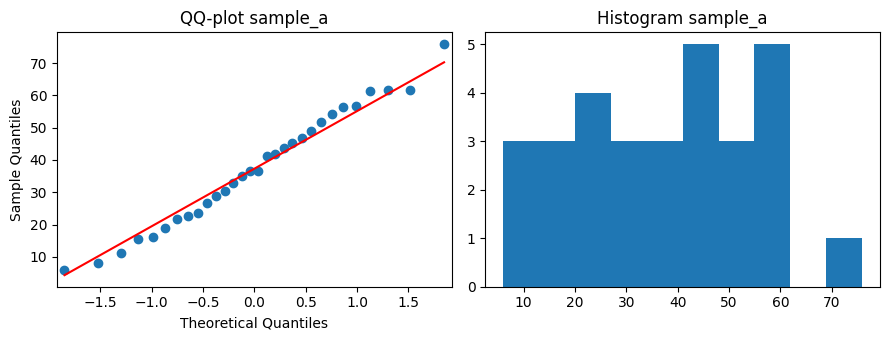

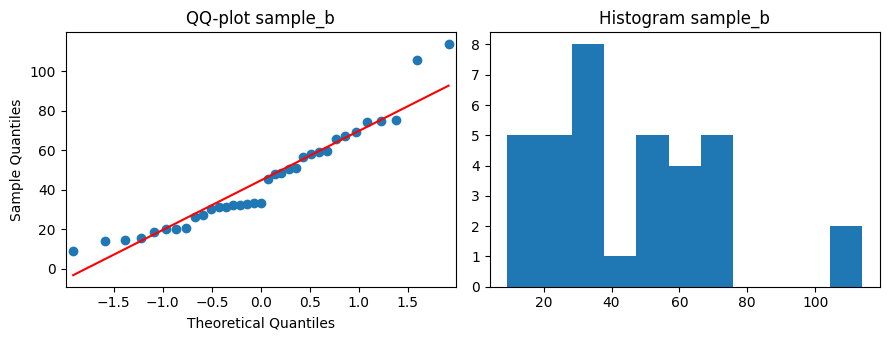

Shapiro-Wilk sample_a: stat=0.978, p=0.7686 -> looks normal (fail to reject)
Shapiro-Wilk sample_b: stat=0.926, p=0.0210 -> NOT normal (reject)
Levene's test A vs B: stat=1.951, p=0.1674 -> equal variances (fail to reject)


In [4]:
# Example usage — adapt to your variables
plot_distribution(sample_a, "sample_a")
plot_distribution(sample_b, "sample_b")
is_normal_a = normality_check(sample_a, "sample_a")
is_normal_b = normality_check(sample_b, "sample_b")
equal_var = variance_check(sample_a, sample_b)

## 3. Test Selection Helper

A small function encoding the decision tree from the Cheat Sheet. It won't
catch every nuance of your specific problem, but it's a good sanity check /
starting suggestion.

In [5]:
def suggest_test(design, normal=None, n_groups=None):
    """
    design: one of 'two_independent', 'paired', 'k_independent',
            'goodness_of_fit', 'independence', 'correlation'
    normal: bool or None — whether normality/equal-variance assumptions hold
            (only relevant for 'two_independent', 'paired', 'k_independent')
    n_groups: int, only used for design='k_independent'
    """
    if design == 'two_independent':
        return "Welch's t-test (parametric)" if normal else "Mann-Whitney U / rank-sum test"
    if design == 'paired':
        return "Paired t-test (parametric)" if normal else "Wilcoxon signed-rank test"
    if design == 'k_independent':
        return "One-way ANOVA (parametric)" if normal else "Kruskal-Wallis test"
    if design == 'goodness_of_fit':
        return "Chi-square goodness-of-fit test"
    if design == 'independence':
        return "Chi-square test of independence"
    if design == 'correlation':
        return "Pearson correlation (parametric)" if normal else "Spearman's rank correlation"
    raise ValueError(f"Unknown design: {design}")

print(suggest_test('two_independent', normal=(is_normal_a and is_normal_b and equal_var)))

Mann-Whitney U / rank-sum test


## 4. Test Runners — one function per test, each returns a tidy result dict

In [6]:
def run_permutation_test(a, b, stat_fn=None, alternative='two-sided', n_resamples=9999, seed=42):
    stat_fn = stat_fn or (lambda x, y: np.mean(x) - np.mean(y))
    res = stats.permutation_test((a, b), stat_fn, alternative=alternative,
                                  n_resamples=n_resamples, random_state=np.random.default_rng(seed))
    return {'test': 'permutation', 'statistic': res.statistic, 'p_value': res.pvalue,
            'null_distribution': res.null_distribution}

def run_mannwhitney(a, b, alternative='two-sided'):
    res = stats.mannwhitneyu(a, b, alternative=alternative)
    n1, n2 = len(a), len(b)
    U_other = n1 * n2 - res.statistic
    r_rb = 1 - (2 * min(res.statistic, U_other)) / (n1 * n2)
    return {'test': 'mann-whitney', 'statistic': res.statistic, 'p_value': res.pvalue,
            'effect_size_rank_biserial': r_rb}

def run_wilcoxon(before, after, alternative='two-sided'):
    res = stats.wilcoxon(before, after, alternative=alternative)
    diffs = np.asarray(before) - np.asarray(after)
    diffs = diffs[diffs != 0]
    ranks = pd.Series(np.abs(diffs)).rank(method='average').values
    S_pos, S_neg = ranks[diffs > 0].sum(), ranks[diffs < 0].sum()
    n = len(diffs)
    r_matched = (S_pos - S_neg) / (n * (n + 1) / 2)
    return {'test': 'wilcoxon', 'statistic': res.statistic, 'p_value': res.pvalue,
            'effect_size_matched_rank_biserial': r_matched}

def run_kruskal(*groups):
    res = stats.kruskal(*groups)
    k, n = len(groups), sum(len(g) for g in groups)
    eta_sq = (res.statistic - k + 1) / (n - k)
    return {'test': 'kruskal-wallis', 'statistic': res.statistic, 'p_value': res.pvalue,
            'effect_size_eta_sq': eta_sq}

def run_posthoc_pairwise(named_groups, alpha=ALPHA):
    """named_groups: dict of {name: array}. Bonferroni-corrected pairwise Mann-Whitney."""
    pairs = list(combinations(named_groups, 2))
    rows = []
    for a, b in pairs:
        stat, p = stats.mannwhitneyu(named_groups[a], named_groups[b])
        rows.append({'group_a': a, 'group_b': b, 'U': stat, 'p_raw': p,
                      'p_bonferroni': min(p * len(pairs), 1.0),
                      'significant': min(p * len(pairs), 1.0) < alpha})
    return pd.DataFrame(rows)

def run_chi2_gof(f_obs, f_exp):
    from statsmodels.stats.gof import chisquare
    from scipy.stats import chi2
    stat, p = chisquare(f_obs=f_obs, f_exp=f_exp)
    n, k = sum(f_obs), len(f_obs)
    crit = chi2.ppf(1 - ALPHA, df=k - 1)
    cohens_w = np.sqrt(stat / n)
    return {'test': 'chi2-goodness-of-fit', 'statistic': stat, 'p_value': p,
            'critical_value': crit, 'effect_size_cohens_w': cohens_w}

def run_chi2_independence(observed, correction=False):
    res = stats.chi2_contingency(observed, correction=correction)
    n = np.sum(observed)
    r, c = observed.shape
    cramers_v = np.sqrt(res.statistic / (n * min(r - 1, c - 1)))
    return {'test': 'chi2-independence', 'statistic': res.statistic, 'p_value': res.pvalue,
            'dof': res.dof, 'expected': res.expected_freq, 'effect_size_cramers_v': cramers_v}

def run_spearman(x, y, bootstrap=True, n_boot=2000, seed=42):
    rho, p = stats.spearmanr(x, y)
    out = {'test': 'spearman', 'rho': rho, 'p_value': p}
    if bootstrap:
        rgen = np.random.default_rng(seed)
        x_arr, y_arr = np.asarray(x), np.asarray(y)
        n = len(x_arr)
        boot = np.empty(n_boot)
        for i in range(n_boot):
            idx = rgen.integers(0, n, size=n)
            boot[i] = stats.spearmanr(x_arr[idx], y_arr[idx]).correlation
        out['ci_95'] = tuple(np.nanpercentile(boot, [2.5, 97.5]))
    return out

## 5. Run + Report Helper

In [7]:
def report(result, alpha=ALPHA):
    """Pretty-print a result dict from any of the run_* functions above."""
    print(f"--- {result['test']} ---")
    for k, v in result.items():
        if k in ('test', 'null_distribution', 'expected'):
            continue
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")
    if 'p_value' in result:
        decision = "REJECT H0" if result['p_value'] < alpha else "FAIL TO REJECT H0"
        print(f"Decision at alpha={alpha}: {decision}")
    print()

In [8]:
# --- Example run: swap in your actual scenario ---
res = run_mannwhitney(sample_a, sample_b, alternative='two-sided')
report(res)

res_kw = run_kruskal(*groups)
report(res_kw)

if res_kw['p_value'] < ALPHA:
    named = {f"g{i}": g for i, g in enumerate(groups)}
    display(run_posthoc_pairwise(named))

res_w = run_wilcoxon(before, after, alternative='two-sided')
report(res_w)

res_chi_ind = run_chi2_independence(observed_table)
report(res_chi_ind)

res_spear = run_spearman(x_var, y_var)
report(res_spear)

--- mann-whitney ---
statistic: 454.0000
p_value: 0.3536
effect_size_rank_biserial: 0.1352
Decision at alpha=0.05: FAIL TO REJECT H0

--- kruskal-wallis ---
statistic: 4.7280
p_value: 0.1928
effect_size_eta_sq: 0.0180
Decision at alpha=0.05: FAIL TO REJECT H0

--- wilcoxon ---
statistic: 28.0000
p_value: 0.0104
effect_size_matched_rank_biserial: -0.6725
Decision at alpha=0.05: REJECT H0

--- chi2-independence ---
statistic: 44.3532
p_value: 0.0000
dof: 4
effect_size_cramers_v: 0.1518
Decision at alpha=0.05: REJECT H0



--- spearman ---
rho: 0.7750
p_value: 0.0000
ci_95: (np.float64(0.5795443604040164), np.float64(0.8713627886571573))
Decision at alpha=0.05: REJECT H0



## 6. Reporting Checklist

Before you call the analysis "done," make sure your final write-up includes:

- [ ] H0 and Ha stated in plain language (not just symbols)
- [ ] Why a non-parametric test was chosen (which assumption failed, and how
      you checked it — plot, formal test, or domain knowledge)
- [ ] Test statistic, degrees of freedom (if applicable), and p-value
- [ ] Decision at your stated α, in plain language
- [ ] An effect size, not just a p-value
- [ ] Sample size and any caveats about power (small n = wide uncertainty,
      even with a "significant" result)
- [ ] For 3+ groups: post-hoc pairwise results if the omnibus test rejected H0
- [ ] A one-paragraph plain-English summary a non-statistician could read

## 7. Extending This Template

- Add a `run_permutation_test` call whenever you need a p-value for a
  non-standard statistic (e.g., a difference in variances, a custom weighted
  score) that none of the named tests cover directly.
- For repeated-measures designs with more than 2 time points, look into the
  Friedman test (`scipy.stats.friedmanchisquare`) — not covered in this lab
  but follows the same pattern as Kruskal-Wallis for paired/repeated data.
- For ordinal regression-style questions (multiple predictors, not just one
  grouping variable), non-parametric tests like these stop being enough — see
  the "Limitations" section of the Background Theory document.